In [1]:
import os
import pickle
import sys
sys.path.append("/data1/morrisq/divyak/projects/metient/notebooks/lineage_tracing")
import lineage_tracing_utilities as lt
import pandas as pd
import torch
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import gzip

from metient.util import plotting_util as plutil
from metient.util import vertex_labeling_util as vutil
from metient.util.globals import *
import metient as met

output_dir = "/data1/morrisq/divyak/projects/metient/notebooks/outputs"

# Change this to where reproducibility data is stored (Download here: https://github.com/divyakoyy/metient_reproducibility)
DATA_DIR = "/data1/morrisq/divyak/data/metient_reproducibility/lung_lineage_tracing"

metient_results_dir = os.path.join(DATA_DIR, "metient_outputs")

In [2]:
    
def site_specifc_clonality(V, A, idx_to_label, sites=None):

    V, A = plutil.prep_V_A_inputs(V, A)
    all_seeding_clusters = plutil.seeding_clusters(V, A, idx_to_label, sites)
    if len(all_seeding_clusters) == 0: # no seeding
        return "no seeding"
    
    site_clonality = "monoclonal" if len(all_seeding_clusters) == 1 else "polyclonal"

    return site_clonality

def weighted_phyleticity(pkl, A, P, depths, node_infos, probabilities, sites):
    '''
    If all nodes can be reached from the top level node in the seeding clusters,
    returns monophyletic, else polyphyletic
    '''
    # probabilities, Vs, As, node_infos = _get_weighted_classification_data(pkl)
    
    Vs = pkl[OUT_LABElING_KEY]
    phyleticities = []
    for i in range(len(Vs)):
        phyleticities.append(plutil.fast_phyleticity(Vs[i], A, P, node_infos[i], depths, sites))
    
    return plutil.weighted_classification(probabilities, phyleticities)

def founding_clone_tissue(V, A, ordered_sites):
    A = A.coalesce()
    gl_node = vutil.get_root_index(A)
    root_node = int(A[gl_node].indices()[0][0])
    root_node_children = A[root_node].coalesce().indices()[0]
    assert len(root_node_children) > 1
    root_tissue_idx = np.where(V[:,root_node]!=0)[0][0]
    return ordered_sites[root_tissue_idx]


In [3]:
import numpy.core.numeric
# alias old module path → new one
sys.modules['numpy._core.numeric'] = numpy.core.numeric

clones = [int(f[:-len('_LL.pkl.gz')]) for f in os.listdir(metient_results_dir) if f.endswith('_LL.pkl.gz')]
clones = sorted(clones)
print(len(clones), "clones")

data = {
    "clone": [],
    "probability": [],
    "phyleticity": [],
    "tissue": [],
    "highest_node_is_founding_clone": [],
    "site clonality": [],
    "tree_idx": [],
}

tissue_to_phyleticity_and_prob = {}
for clone in clones:
    print("\nClone", clone)
    with gzip.open(os.path.join(metient_results_dir,f"{clone}_LL.pkl.gz") ,"rb") as f:
        pckl = pickle.load(f)
        
    num_solutions = len(pckl[OUT_LABElING_KEY])
    print(f"{num_solutions} solutions")
    ordered_sites = pckl[OUT_SITES_KEY]
    losses = pckl[OUT_LOSSES_KEY]
    A = met.adjacency_matrix_from_parents(pckl[OUT_PARENTS_KEY][0])
    print(A.shape)
    P = vutil.path_matrix(A, remove_self_loops=False).to_dense()
    depths = plutil.compute_depths(A, P)
    probs = plutil.losses_to_probabilities(losses, temperature=0.05)
    print(probs)
    mig_graphs = []
    pars_metrics = []
    unnormed_tissue_trans = torch.zeros((len(lt.TISSUE_ORDER),len(lt.TISSUE_ORDER)))
    node_infos = [vutil.MigrationHistoryNodeCollection.from_dict(x) for x in pckl['node_info']]
    for tissue in ordered_sites:
        phyl = weighted_phyleticity(pckl, A, P, depths, node_infos, probs, [ordered_sites.index(tissue)])
        for tree_idx,prob in enumerate(probs):
            V = pckl[OUT_LABElING_KEY][tree_idx]
            node_info = node_infos[tree_idx]
            tissue_of_founding_clone = founding_clone_tissue(V,A,ordered_sites)
            
            site_clonality = site_specifc_clonality(V, A, node_info, sites=[ordered_sites.index(tissue)])

            # phyl, clonality = fast_phyleticity_and_site_clonality(V, A, P, node_info, depths, sites=[ordered_sites.index(tissue)])
            
            #print("solution:", tree_idx, "tissue:", tissue, "phyleticity:", phyl, "site clonality", clonality)
            data["clone"].append(clone)
            data["probability"].append(prob)
            data["phyleticity"].append(phyl)
            data["tissue"].append(tissue)
            data["site clonality"].append(site_clonality)
            data["highest_node_is_founding_clone"].append(tissue_of_founding_clone==tissue)
            data["tree_idx"].append(tree_idx)

df = pd.DataFrame(data)

100 clones

Clone 1
26 solutions
torch.Size([26541, 26541])


/data1/morrisq/divyak/projects/metient/metient/util/data_extraction_util.py:35: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  parents = torch.tensor(parents)[mask]


[9.99999519e-01 7.60973842e-08 6.03115658e-08 5.06611342e-08
 4.48815915e-08 3.98946814e-08 2.79766536e-08 2.29482258e-08
 2.04007635e-08 2.02631181e-08 1.65266489e-08 1.45453497e-08
 1.32551889e-08 1.25205310e-08 1.06171224e-08 1.02376355e-08
 9.58680079e-09 6.96913609e-09 3.71637873e-09 3.47770694e-09
 3.41997136e-09 3.39033370e-09 2.52829036e-09 2.24884042e-09
 2.20763630e-09 2.06115263e-09]

Clone 2
42 solutions
torch.Size([21068, 21068])
[9.99999661e-01 4.28002477e-08 3.61124393e-08 2.71590437e-08
 2.00077751e-08 1.77052522e-08 1.05943015e-08 1.01661105e-08
 1.00916242e-08 9.90142498e-09 8.65761280e-09 8.25450067e-09
 8.02714678e-09 7.98615348e-09 7.76462715e-09 7.47692371e-09
 7.24235616e-09 6.82130782e-09 6.70472324e-09 6.50307342e-09
 5.33176064e-09 5.13838834e-09 5.07160248e-09 4.99877833e-09
 4.83407001e-09 4.46895493e-09 4.20178496e-09 4.16456526e-09
 4.06715709e-09 3.47541154e-09 3.38968338e-09 3.33416218e-09
 3.16758513e-09 2.97804434e-09 2.82974751e-09 2.72116316e-09
 2.7

In [4]:
def consensus_tissue_by_weighted_average(df):
    # Step 1: Filter rows where highest_node_is_founding_clone is True
    filtered_df = df[df['highest_node_is_founding_clone'] == True]

    # Step 2: Group by clone and tissue to calculate the weighted sum of probabilities
    weighted_avg_df = (filtered_df.groupby(['clone', 'tissue'])
                       .agg(weighted_probability=('probability', 'sum'))
                       .reset_index())

    # Step 3: For each clone, find the tissue with the highest weighted probability
    consensus_tissue_df = (weighted_avg_df.loc[weighted_avg_df.groupby('clone')['weighted_probability'].idxmax()]
                           .rename(columns={'tissue': 'consensus_tissue'}))

    # Step 4: Return DataFrame with clone and the consensus tissue
    return consensus_tissue_df[['clone', 'consensus_tissue', 'weighted_probability']]

def percentage_founding_clones_by_tissue(df):
    # Step 1: Get the consensus tissue for each clone using the weighted average function
    consensus_df = consensus_tissue_by_weighted_average(df)
    
    # Step 2: Count how many times each tissue is the consensus founding clone
    tissue_counts = consensus_df['consensus_tissue'].value_counts()
    
    # Step 3: Calculate the percentage for each tissue
    total_clones = len(consensus_df)  # Total number of unique clones
    tissue_percentage = (tissue_counts / total_clones) * 100
    
    # Step 4: Return the percentages as a DataFrame
    tissue_percentage_df = tissue_percentage.reset_index()
    tissue_percentage_df.columns = ['tissue', 'percentage_founding_clone']
    
    return tissue_percentage_df

percent_founding_clones_by_tissue = percentage_founding_clones_by_tissue(df)
percent_founding_clones_by_tissue

,tissue,percentage_founding_clone
0,M1,63.000
1,M2,12.000
2,RE,10.000
3,LL,9.000
4,RW,5.000
5,Liv,1.000


In [5]:
# Function to compute the weighted classification of phyleticity for each clone-tissue combo
def weighted_classification_phyleticity(group):
    return weighted_classification(group, "phyleticity")

def weighted_classification_clonality(group):
    return weighted_classification(group, "site clonality")

def weighted_classification(group,attr):
    # Get the unique phyleticity values
    phyleticities = group[attr].unique()
    
    # Initialize a dictionary to hold the weighted sum of probabilities for each phyleticity
    weighted_probs = {phyleticity: 0 for phyleticity in phyleticities}
    
    # Sum the weighted probabilities for each phyleticity
    for index, row in group.iterrows():
        weighted_probs[row[attr]] += row['probability']
    
    # Determine the phyleticity with the highest total weight
    most_probable_phyleticity = max(weighted_probs, key=weighted_probs.get)
    
    # Return the weighted classification
    return pd.Series({
        f'weighted_{attr}': most_probable_phyleticity,
        'weighted_probabilities': weighted_probs
    })


# Group by 'clone' and 'tissue', then apply the weighted classification function
weighted_phyleticity = df.groupby(['clone', 'tissue']).apply(weighted_classification_phyleticity).reset_index()
weighted_clonality = df.groupby(['clone', 'tissue']).apply(weighted_classification_clonality).reset_index()

weighted_clonality


/tmp/ipykernel_93780/1189788158.py:30: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  weighted_phyleticity = df.groupby(['clone', 'tissue']).apply(weighted_classification_phyleticity).reset_index()
/tmp/ipykernel_93780/1189788158.py:31: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  weighted_clonality = df.groupby(['clone', 'tissue']).apply(weighted_classification_clonality).reset_index()


,clone,tissue,weighted_site clonality,weighted_probabilities
0,1,LL,polyclonal,"{'polyclonal': 0.9999999838177303, 'no seeding..."
1,1,Liv,polyclonal,{'polyclonal': 1.0000000000000002}
2,1,M1,polyclonal,{'polyclonal': 1.0000000000000002}
3,1,M2,polyclonal,{'polyclonal': 1.0000000000000002}
4,1,RE,polyclonal,{'polyclonal': 1.0000000000000002}
...,...,...,...,...
513,100,Liv,polyclonal,{'polyclonal': 1.0}
514,100,M1,monoclonal,"{'monoclonal': 0.9999999979388463, 'polyclonal..."
515,100,M2,polyclonal,{'polyclonal': 1.0}
516,100,RE,monoclonal,{'monoclonal': 1.0}


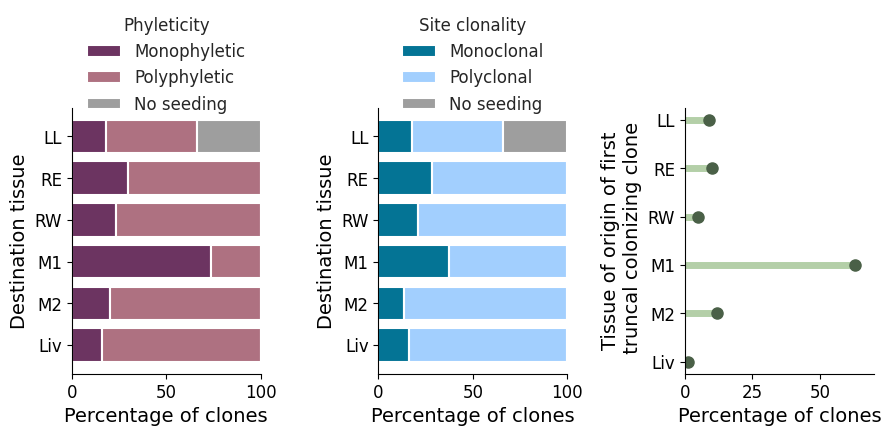

In [6]:
def horizontal_bar(proportions, desired_order, tab_colors, legend_title, output_name, ax):
    # Variables to store the bottom for each bar (cumulative stacking)
    bottoms = np.zeros(len(proportions))

    # Colors for each category
    colors = {d: c for d, c in zip(desired_order, tab_colors)}

    sns.set(style='ticks', font="Arial")

    # Plot each category (phyleticity type)
    for column_name in desired_order:
        column_data = proportions[column_name]
        ax.barh(proportions.index, column_data, left=bottoms, label=column_name, 
                color=colors[column_name], edgecolor='white', linewidth=1.5)
        bottoms += column_data.values  # Update the bottom for stacking

    # Labels and legend
    ax.set_xlabel(f'Percentage of clones', fontsize=14)
    ax.set_ylabel('Destination tissue', fontsize=14)
    ax.tick_params(axis='both', which='major', labelsize=12)
    
    # Reverse y-axis tick labels
    ax.invert_yaxis()

    legend = ax.legend(title=legend_title, bbox_to_anchor=(0.5, 1.4), 
                      loc='upper center', frameon=False, fontsize=12)

    for text in legend.get_texts():
        text.set_text(text.get_text().capitalize())  # Capitalize legend text
    
    # Remove top and right axes for a cleaner look
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

# Create figure with three subplots side by side
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(9, 5))

# First plot - Phyleticity
phyleticity_counts = weighted_phyleticity.groupby(['tissue', 'weighted_phyleticity']).size().unstack(fill_value=0)
phyleticity_proportions = (phyleticity_counts.div(phyleticity_counts.sum(axis=1), axis=0) * 100).reindex(lt.TISSUE_ORDER)
colors = ["#6c3461", "#ae7181", "#9e9e9e"]
horizontal_bar(phyleticity_proportions, ['monophyletic', 'polyphyletic', 'no seeding'], colors,
               "Phyleticity", "phyleticity_by_tissue", ax1)

# Second plot - Clonality  
clonality_counts = weighted_clonality.groupby(['tissue', 'weighted_site clonality']).size().unstack(fill_value=0)
clonality_proportions = (clonality_counts.div(clonality_counts.sum(axis=1), axis=0) * 100).reindex(lt.TISSUE_ORDER)
colors = ["#047495", "#a2cffe", "#9e9e9e"]
horizontal_bar(clonality_proportions, ['monoclonal', 'polyclonal', 'no seeding'], colors,
               "Site clonality", "site_clonality_by_tissue", ax2)

# Third plot - Founding clone percentages
percent_founding_clones_by_tissue['tissue'] = pd.Categorical(percent_founding_clones_by_tissue['tissue'], categories=lt.TISSUE_ORDER, ordered=True)
percent_founding_clones_by_tissue = percent_founding_clones_by_tissue.sort_values('tissue')

ax3.hlines(y=percent_founding_clones_by_tissue['tissue'], xmin=0, xmax=percent_founding_clones_by_tissue['percentage_founding_clone'], 
           color='#a1c492', alpha=0.8, linewidth=5)
ax3.plot(percent_founding_clones_by_tissue['percentage_founding_clone'], percent_founding_clones_by_tissue['tissue'], 
         "o", color='#4a6047', ms=8)

ax3.set_xlim(0, 70)
ax3.tick_params(axis='both', which='major', labelsize=12)
ax3.set_xlabel('Percentage of clones', fontsize=14)
ax3.set_ylabel('Tissue of origin of first\n truncal colonizing clone', fontsize=14)

# Reverse y-axis tick labels for third plot
ax3.invert_yaxis()

ax3.spines['top'].set_visible(False)
ax3.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig(os.path.join(output_dir,"combined_plots.svg"), dpi=300, bbox_inches='tight', pad_inches=0.3)
plt.show()
plt.close()
